Processing: Fincha_Daily_Observed & Simulated_PCP_RCP4.5.csv
RMSE = 97.21940719097073
Percent Bias = -43.91869662003488
NSE = 0.5213221325124434
R² = 0.7355813054258178
RSR =  0.6918654981190756
STD_OBS =  140.51778482273514
Processing: Fincha_Daily_Observed & Simulated_PCP_RCP8.5.csv
RMSE = 99.40355077314732
Percent Bias = -43.35764156180668
NSE = 0.49957245507228243
R² = 0.7073343313602227
RSR =  0.7074090365041413
STD_OBS =  140.51778482273514
Processing: Neshe_Daily_Observed & Simulated_PCP_RCP4.5.csv
RMSE = 48.914037845205065
Percent Bias = -49.50327967970343
NSE = 0.4356844696084483
R² = 0.6739264132514384
RSR =  0.7512093785300819
STD_OBS =  65.11372094543988
Processing: Neshe_Daily_Observed & Simulated_PCP_RCP8.5.csv
RMSE = 73.09707933381947
Percent Bias = -78.42629465583087
NSE = -0.26024511113734783
R² = 0.6916178631926503
RSR =  1.1226063919011633
STD_OBS =  65.11372094543988
Processing: Shambu_Daily_Observed & Simulated_PCP-RCP4.5.csv
RMSE = 131.54053834225832
Percent Bias 

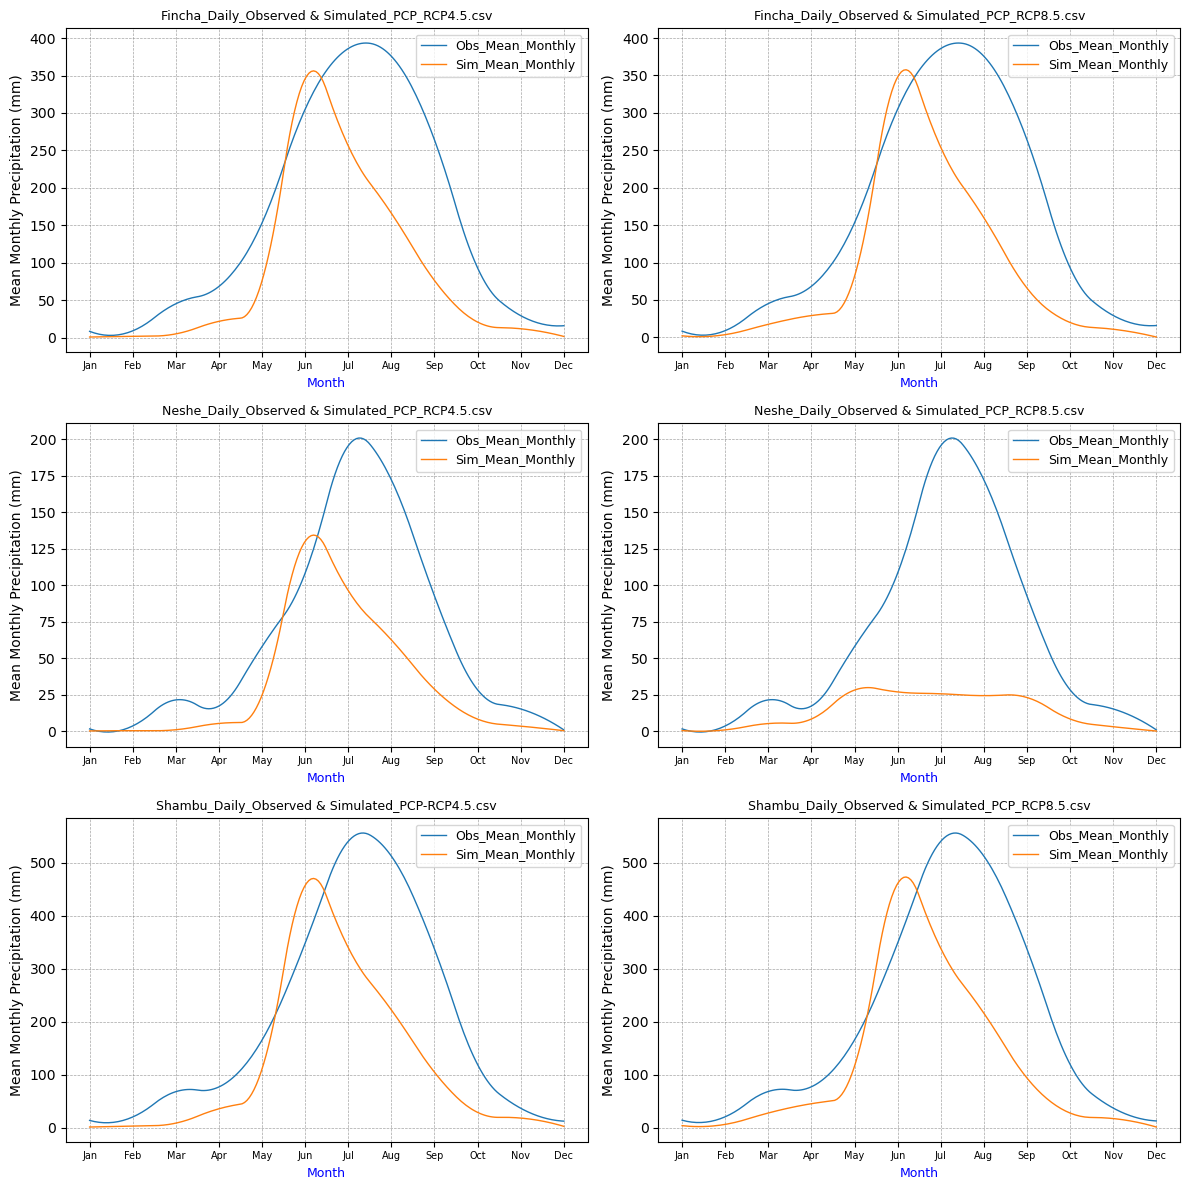

<Figure size 1000x600 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import math
import seaborn as sns

# Folder containing CSV files
folder_path = "C:\\Users\\SANYI\\Desktop\\Data Analysis"

# Read all csv files
files = glob.glob(folder_path + "\\*.csv")
if len(files) == 1:
    axes = [axes]

n = len(files)
# Define grid size automatically
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
axes = axes.flatten()  # flatten for easy looping


# Create ONE figure before loop
plt.figure(figsize=(10,6))

for i ,file in enumerate(files):

    print("Processing:", os.path.basename(file))

    df = pd.read_csv(file)

    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month

    monthly = df.groupby(["Year","Month"])[["Observed","Simulated"]].sum().reset_index()

    mean_monthly = monthly.groupby("Month")[["Observed","Simulated"]].mean().reset_index()
    mean_monthly = mean_monthly.sort_values("Month")

    mean_monthly.rename(columns={
        "Observed":"Obs_Mean_Monthly",
        "Simulated":"Sim_Mean_Monthly"
    }, inplace=True)

    # IQR cleaning
    data = mean_monthly[["Obs_Mean_Monthly","Sim_Mean_Monthly"]]

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_clean = data.mask((data < lower) | (data > upper))
    data_clean = data_clean.interpolate(method="linear")

    
    #Statistical Metrices After Outliers Check/Cleaning
    std_obs_new = np.std(data_clean["Obs_Mean_Monthly"])
    
    rmse_new = np.sqrt(np.mean(
    (data_clean["Sim_Mean_Monthly"] - data_clean["Obs_Mean_Monthly"])**2))
    
    rsr_new = rmse_new / std_obs_new
    
    r2 = np.corrcoef(data_clean["Obs_Mean_Monthly"], data_clean["Sim_Mean_Monthly"])[0,1]**2
    
    pbias = 100 * np.sum(data_clean["Sim_Mean_Monthly"] - data_clean["Obs_Mean_Monthly"]) / np.sum(data_clean["Obs_Mean_Monthly"])
    
    nse = 1 - (
        np.sum((data_clean["Obs_Mean_Monthly"] -
                data_clean["Sim_Mean_Monthly"])**2) /
        np.sum((data_clean["Obs_Mean_Monthly"] -
                np.mean(data_clean["Obs_Mean_Monthly"]))**2)
    )
    
    print("RMSE =", rmse_new)
    print("Percent Bias =", pbias)
    print("NSE =", nse)
    print("R² =", r2)
    print("RSR = " , rsr_new)
    print("STD_OBS = " ,std_obs_new)

    
    # X and Y
    X = mean_monthly["Month"]
    Y_obs = data_clean["Obs_Mean_Monthly"]
    Y_sim = data_clean["Sim_Mean_Monthly"]

    # Smooth curve
    X_smooth = np.linspace(X.min(), X.max(), 200)

    spline_obs = make_interp_spline(X, Y_obs, k=2)
    spline_sim = make_interp_spline(X, Y_sim, k=2)

    Y_obs_smooth = spline_obs(X_smooth)
    Y_sim_smooth = spline_sim(X_smooth)
    
    ax = axes[i]
    ax.plot(X_smooth, Y_obs_smooth, label="Obs_Mean_Monthly",linewidth=1.0, alpha=1.0)
    ax.plot(X_smooth, Y_sim_smooth, label="Sim_Mean_Monthly",linewidth=1.0, alpha=1.0)
    
    ax.set_xlabel("Month", fontsize=9, color="blue")
    ax.set_ylabel("Mean Monthly Precipitation (mm)",)
    
    ax.set_title(os.path.basename(file), fontsize=9)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=7)

    ax.set_title(os.path.basename(file), fontsize=9)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=7)
    
    ax.legend(fontsize=9)
    ax.set_facecolor("white")
    
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)   

# Save the SPECIFIC figure object, not plt
fig.tight_layout()
fig.savefig("Precipitation_Statistical_Metrics.png", dpi=300, bbox_inches='tight')

plt.show()
